In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()
uploaded_names = list(uploaded.keys())

sudoku_matches = [
    name for name in uploaded_names
    if 'sudoku' in name.lower()
]

if sudoku_matches:
  image_path = '/content/' + sudoku_matches[0]

else:
  image_path = '/content/' + uploaded_names[0]

print('Input Image:', image_path)

Saving sudoku.jpg to sudoku.jpg
Input Image: /content/sudoku.jpg


In [6]:
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    raise ValueError("Error: Unable To Read The Image.")

noise_removed_image = cv2.medianBlur(original_image, 5)

_, output1 = cv2.threshold(original_image, 127, 255, cv2.THRESH_BINARY)

output2 = cv2.adaptiveThreshold(original_image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

output3 = cv2.adaptiveThreshold(original_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

_, output4 = cv2.threshold(noise_removed_image, 127, 255, cv2.THRESH_BINARY)

output5 = cv2.adaptiveThreshold(noise_removed_image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

output6 = cv2.adaptiveThreshold(noise_removed_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

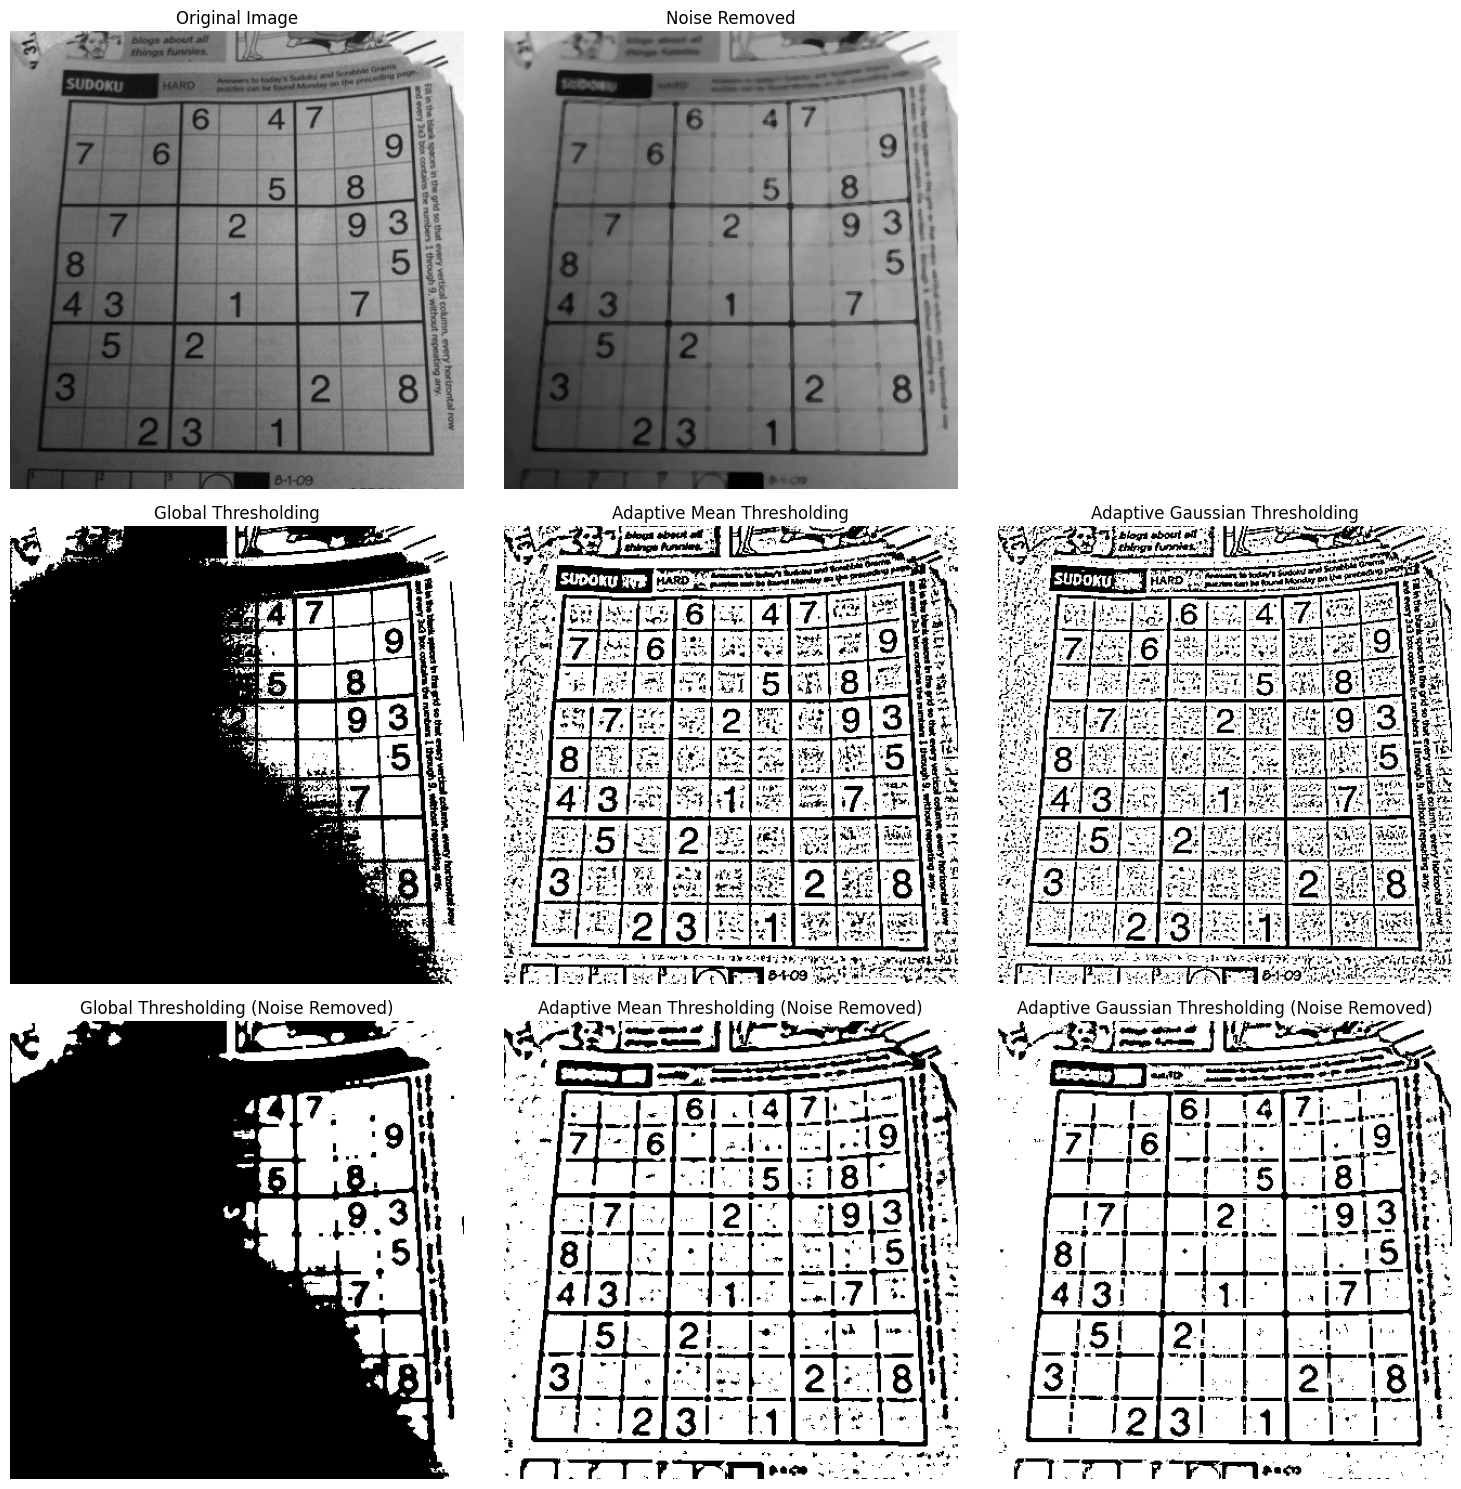

In [7]:
plt.figure(figsize=(15, 15))

plt.subplot(3, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(noise_removed_image, cmap='gray')
plt.title('Noise Removed')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(output1, cmap='gray')
plt.title('Global Thresholding')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(output2, cmap='gray')
plt.title('Adaptive Mean Thresholding')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(output3, cmap='gray')
plt.title('Adaptive Gaussian Thresholding')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(output4, cmap='gray')
plt.title('Global Thresholding (Noise Removed)')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(output5, cmap='gray')
plt.title('Adaptive Mean Thresholding (Noise Removed)')
plt.axis('off')

plt.subplot(3, 3, 9)
plt.imshow(output6, cmap='gray')
plt.title('Adaptive Gaussian Thresholding (Noise Removed)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
outputs = {
    'sudoku_global.png': output1,
    'sudoku_adaptive_mean.png': output2,
    'sudoku_adaptive_gaussian.png': output3,
    'sudoku_global_denoised.png': output4,
    'sudoku_adaptive_mean_denoised.png': output5,
    'sudoku_adaptive_gaussian_denoised.png': output6,
}

for filename, output_image in outputs.items():
    cv2.imwrite('/content/' + filename, output_image)
    files.download(filename)
    print('Saved:', filename)
    print(f'Downloaded: {filename}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: sudoku_global.png
Downloaded: sudoku_global.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Saved: sudoku_adaptive_mean_denoised.png
Downloaded: sudoku_adaptive_mean_denoised.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: sudoku_adaptive_gaussian_denoised.png
Downloaded: sudoku_adaptive_gaussian_denoised.png
